# Online Retail II — Notebook 2: Exploratory Analysis & Insights

*Second of two notebooks.* [Notebook 1](01_data_preparation.ipynb) assessed data
quality and saved a clean, analysis-ready dataset. Here we explore it and tell the story the
data supports — from headline commercial patterns to customer segments, retention, product
affinity, and a first predictive baseline.

**The arc:** where the money is (time, geography, customers, products) → *why* prices vary →
how returns behave → *who* the customers are (RFM) → do they come back (cohorts) → what sells
together (market basket) → can we predict repeat purchase — then findings and recommendations.

Everything is computed in-notebook; each number is produced by a visible cell.

## Setup & the analysis views

In [1]:
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path
from itertools import combinations
from collections import Counter
import numpy as np, pandas as pd, re
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

NAVY, TEAL, LBLUE, CORAL, GRAY = "#14213D", "#0FA3B1", "#7DCFDD", "#E07A5F", "#9AA5B1"
plt.rcParams.update({
    "figure.figsize": (9, 4.4), "figure.dpi": 110, "font.size": 11,
    "axes.titleweight": "bold", "axes.titlecolor": NAVY, "axes.labelcolor": NAVY,
    "axes.edgecolor": GRAY, "axes.grid": True, "grid.color": "#ECEFF2",
    "text.color": NAVY, "xtick.color": NAVY, "ytick.color": NAVY,
    "axes.spines.top": False, "axes.spines.right": False,
})
money = lambda x, _=None: (f"£{x/1e6:.1f}M" if abs(x) >= 1e6 else f"£{x/1e3:.0f}k")

# Load the prepared dataset from Notebook 1
prep = pd.read_parquet(Path("..") / "data" / "online_retail_prepared.parquet")

# Analysis views: clean merchandise SALES, merchandise RETURNS, and identified customers.
sales   = prep[(prep["nature"]=="Merchandise") & (~prep["is_cancellation"]) &
               (prep["Quantity"]>0) & (prep["Price"]>0)].copy()
returns = prep[(prep["nature"]=="Merchandise") & (prep["is_cancellation"])].copy()
print(f"merchandise sales: {len(sales):,} lines, £{sales['Revenue'].sum():,.0f}")
print(f"merchandise returns: {len(returns):,} lines, £{returns['Revenue'].sum():,.0f}")
print(f"identified customers: {sales['Customer ID'].nunique():,} "
      f"({sales['Customer ID'].isna().mean()*100:.0f}% of sale lines have no customer)")

merchandise sales: 1,003,357 lines, £19,643,862
merchandise returns: 17,915 lines, £-716,463
identified customers: 5,852 (23% of sale lines have no customer)


## 1. Revenue over time & seasonality

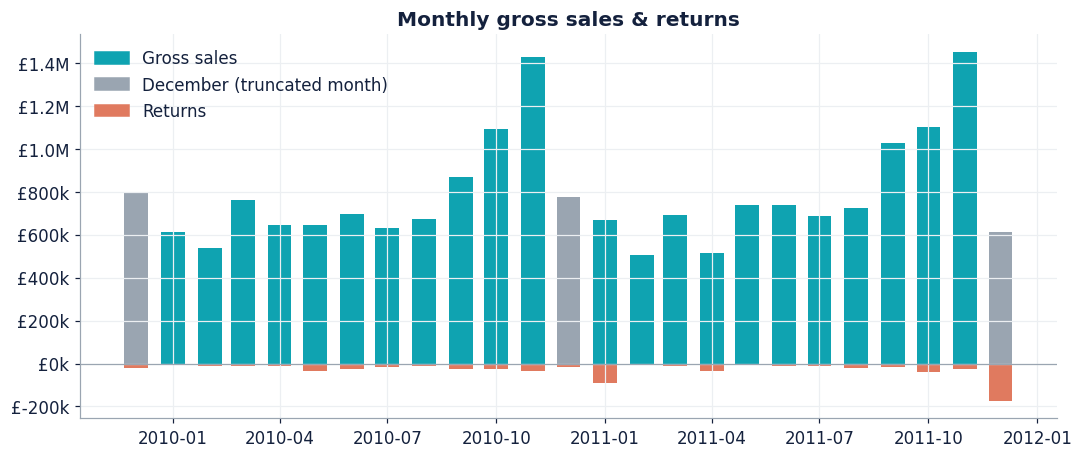

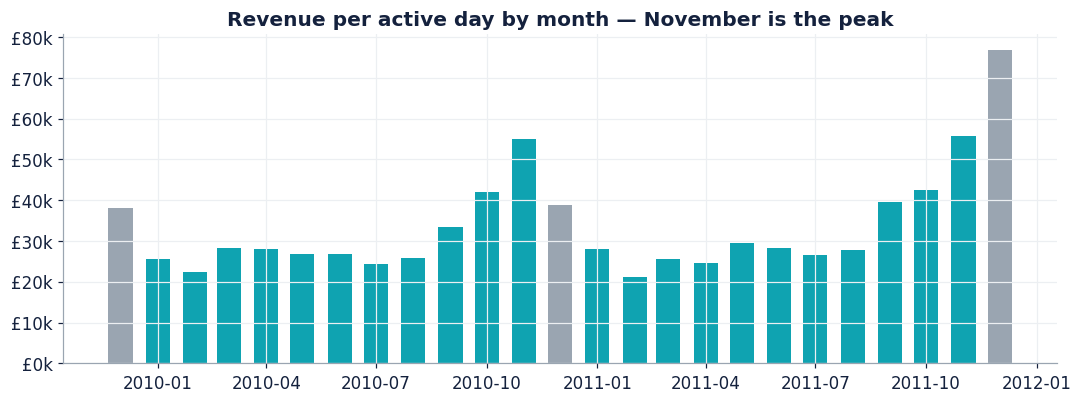

  2010-11: £55k/day over 26 active days
  2010-12: £39k/day over 20 active days
  2011-11: £56k/day over 26 active days
  2011-12: £77k/day over 8 active days


In [2]:
sales["month"] = sales["InvoiceDate"].dt.to_period("M").dt.to_timestamp()
sales["date"]  = sales["InvoiceDate"].dt.date
returns["month"] = returns["InvoiceDate"].dt.to_period("M").dt.to_timestamp()
m_rev = sales.groupby("month")["Revenue"].sum()
m_ret = returns.groupby("month")["Revenue"].sum().reindex(m_rev.index).fillna(0)
from matplotlib.patches import Patch
colors = [GRAY if m == 12 else TEAL for m in m_rev.index.month]  # grey = truncated Decembers

fig, ax = plt.subplots(figsize=(10, 4.3))
ax.bar(m_rev.index, m_rev.values, width=20, color=colors)
ax.bar(m_ret.index, m_ret.values, width=20, color=CORAL)
ax.axhline(0, color=GRAY, lw=0.8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(money))
ax.legend(handles=[Patch(color=TEAL, label="Gross sales"),
                   Patch(color=GRAY, label="December (truncated month)"),
                   Patch(color=CORAL, label="Returns")], frameon=False, loc="upper left")
ax.set_title("Monthly gross sales & returns")
plt.tight_layout(); plt.show()

# normalise for month length: revenue per ACTIVE day
mday = (sales.assign(ym=sales["InvoiceDate"].dt.to_period("M"))
             .groupby("ym").agg(rev=("Revenue","sum"), days=("date","nunique")))
mday["per_day"] = mday["rev"] / mday["days"]
idx = mday.index.to_timestamp()
fig, ax = plt.subplots(figsize=(10, 3.8))
ax.bar(idx, mday["per_day"].values, width=20,
       color=[GRAY if t.month == 12 else TEAL for t in idx])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(money))
ax.set_title("Revenue per active day by month — November is the peak")
plt.tight_layout(); plt.show()
for ym in ["2010-11","2010-12","2011-11","2011-12"]:
    print(f"  {ym}: £{mday.loc[ym,'per_day']/1e3:.0f}k/day over {int(mday.loc[ym,'days'])} active days")

Demand builds through autumn to a **November peak** in both years. December can't be read as a
peak: the business closes ~23 Dec (so late-December is never observed) and — as flagged in
Notebook 1 — 2010's December is distorted by a duplicate-row cluster. Returns (coral) are small
relative to sales but present every month.

## 2. Geographic concentration

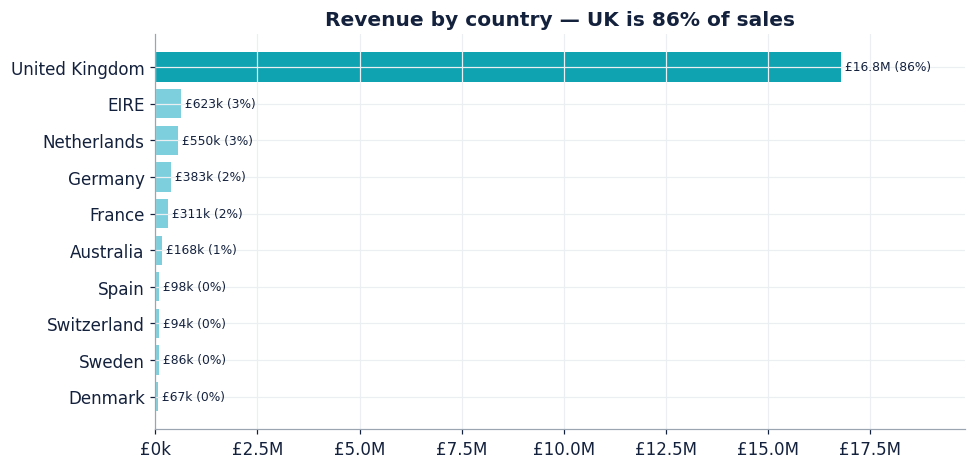

UK is 92% of ORDERS but 86% of REVENUE -> overseas orders are larger on average.


In [3]:
by_country = sales.groupby("Country")["Revenue"].sum().sort_values(ascending=False)
uk_rev = by_country["United Kingdom"] / by_country.sum() * 100
uk_ord = sales[sales["Country"]=="United Kingdom"]["Invoice"].nunique() / sales["Invoice"].nunique() * 100
top = by_country.head(10)[::-1]
fig, ax = plt.subplots()
ax.barh(top.index, top.values, color=[TEAL if c=="United Kingdom" else LBLUE for c in top.index])
ax.xaxis.set_major_formatter(mticker.FuncFormatter(money))
for i,(c,v) in enumerate(top.items()):
    ax.text(v, i, f" {money(v)} ({v/by_country.sum()*100:.0f}%)", va="center", fontsize=8, color=NAVY)
ax.set_xlim(0, top.max()*1.18); ax.set_title(f"Revenue by country — UK is {uk_rev:.0f}% of sales")
plt.tight_layout(); plt.show()
print(f"UK is {uk_ord:.0f}% of ORDERS but {uk_rev:.0f}% of REVENUE -> overseas orders are larger on average.")

## 3. Customer concentration

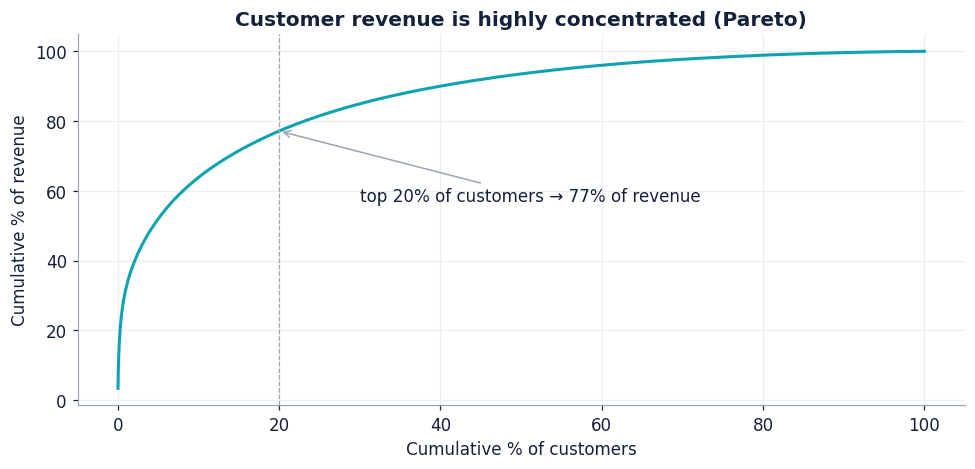

5,852 identified customers | top 20% = 77% of revenue | median £856 | mean £2,917


In [4]:
cust_rev = (sales.dropna(subset=["Customer ID"]).groupby("Customer ID")["Revenue"].sum()
                 .sort_values(ascending=False))
cum = (cust_rev.cumsum()/cust_rev.sum()).values
rank = np.arange(1, len(cust_rev)+1)/len(cust_rev)*100
top20 = cum[int(0.2*len(cust_rev))-1]*100
fig, ax = plt.subplots()
ax.plot(rank, cum*100, color=TEAL, lw=2)
ax.axvline(20, color=GRAY, ls="--", lw=0.8)
ax.annotate(f"top 20% of customers → {top20:.0f}% of revenue", (20, top20),
            xytext=(30, top20-20), color=NAVY, arrowprops=dict(arrowstyle="->", color=GRAY))
ax.set_title("Customer revenue is highly concentrated (Pareto)")
ax.set_xlabel("Cumulative % of customers"); ax.set_ylabel("Cumulative % of revenue")
plt.tight_layout(); plt.show()
print(f"{len(cust_rev):,} identified customers | top 20% = {top20:.0f}% of revenue "
      f"| median £{cust_rev.median():,.0f} | mean £{cust_rev.mean():,.0f}")

## 4. Products & categories

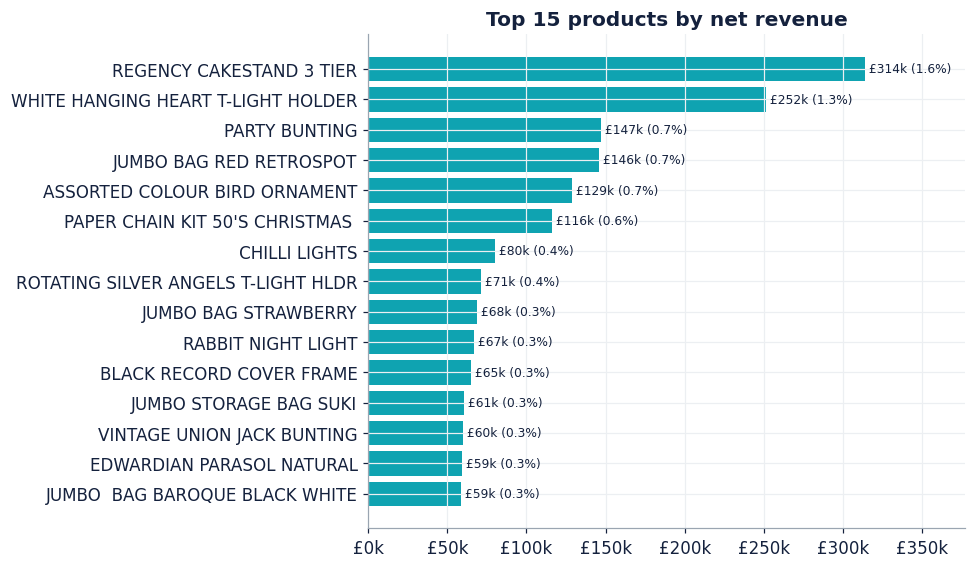

In [5]:
s_desc = sales.groupby("Description")["Revenue"].sum()
r_desc = returns.groupby("Description")["Revenue"].sum()
net = s_desc.add(r_desc, fill_value=0).sort_values(ascending=False).head(15)[::-1]
tot = sales["Revenue"].sum()
fig, ax = plt.subplots(figsize=(9,5.3))
ax.barh(net.index, net.values, color=TEAL)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(money))
for i,(nm,v) in enumerate(net.items()):
    ax.text(v, i, f" {money(v)} ({v/tot*100:.1f}%)", va="center", fontsize=8, color=NAVY)
ax.set_xlim(0, net.max()*1.2); ax.set_title("Top 15 products by net revenue")
plt.tight_layout(); plt.show()

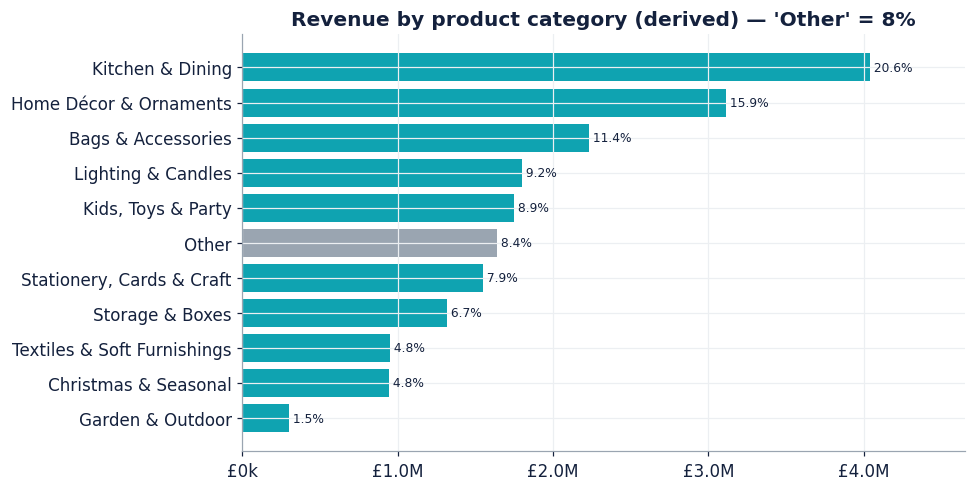

Kitchen & Dining + Home Décor = 36% of sales.

Top items still in 'Other' (heuristic misses):
Description
WOOD BLACK BOARD ANT WHITE FINISH    £56,746
VINTAGE UNION JACK MEMOBOARD         £45,402
MINI PAINT SET VINTAGE               £27,056
DOOR MAT UNION FLAG                  £24,771
ENAMEL BREAD BIN CREAM               £20,887
CLOTHES PEGS RETROSPOT PACK 24       £19,513


In [6]:
# Derive product categories from the free-text Description (ordered keyword rules, first match).
RULES = [
 ("Christmas & Seasonal",  r"CHRISTMAS|XMAS|ADVENT|EASTER|HALLOWE|SANTA|REINDEER|SNOWMAN|NATIVITY"),
 ("Kids, Toys & Party",    r"TOY|KID|CHILDREN|PARTY|DOLL|GAME|PLAYHOUSE|SPACEBOY|SPACEGIRL|PIGGY|SKITTLE|JIGSAW|BALLOON|CRAYON|MODELLING|SKIPPING|SPINNING TOP|BINGO|SNAKES|COLOURING|FELTCRAFT|DOMINOES|CHALK|SLEDGE"),
 ("Lighting & Candles",    r"T-?LIGHT|TEA ?LIGHT|NIGHT ?LIGHT| LIGHT|LIGHTS|LANTERN|CANDLE|LAMP|LED |FAIRY LIGHT"),
 ("Kitchen & Dining",      r"MUG|CUP|BOWL|PLATE|TEAPOT|TEA SET|TEA GLASS|CAKE|BAKING|JUG|CUTLER|TEA TOWEL|BOTTLE|JAR|TRAY|EGG|KITCHEN|SPOON|COOK|CANISTER|COFFEE|SAUCER|MOULD|JELLY|JAM MAKING|PANTRY|RECIPE|COLANDER|TEACUP"),
 ("Textiles & Soft Furnishings", r"CUSHION|PAD|THROW|BLANKET|RUG|TOWEL|NAPKIN|PLACEMAT|TEA COSY|HOT WATER BOTTLE|DOORMAT|HAND WARMER|APRON"),
 ("Bags & Accessories",    r"BAG|SHOPPER|TOTE|CASH\+CARRY|PURSE|WALLET|NECKLACE|BRACELET|EARRING|BANGLE|SCARF|GLOVE|UMBRELLA|PARASOL|HAT|KEY FOB|KEYRING|SILK FAN"),
 ("Stationery, Cards & Craft", r"CARD|NOTEBOOK|PAPER|WRAP|PEN |PENCIL|CHALKBOARD|STICKER|POSTCARD|GREETING|NOTELET|GIFT TAG|ENVELOPE|RIBBON|CRAFT|SEWING|FELT|GLITTER|TISSUE|DOILY|STATIONERY"),
 ("Home Décor & Ornaments", r"HEART|HANGING|DECORATION|ORNAMENT|FRAME|MIRROR|CLOCK|SIGN|VASE|HOOK|DOORSTOP|WALL ART|CANDLESTICK|BUNTING|GARLAND|BLOCK WORD|WICKER|CHANDELIER|CABINET|WOODEN STAR"),
 ("Storage & Boxes",       r"BOX|TIN|STORAGE|BASKET|TRUNK|DRAWER|CRATE|HOLDER|RACK|CADDY|CASE"),
 ("Garden & Outdoor",      r"GARDEN|PLANT|WATERING|BIRD|DECKCHAIR|FLOWER|WINDMILL|SEED"),
]
def categorize(desc):
    d = str(desc).upper()
    for cat, pat in RULES:
        if re.search(pat, d): return cat
    return "Other"
cat_map = {d: categorize(d) for d in sales["Description"].dropna().unique()}
sales["category"] = sales["Description"].map(cat_map).fillna("Other")
cat = sales.groupby("category")["Revenue"].sum().sort_values()
fig, ax = plt.subplots(figsize=(9,4.6))
ax.barh(cat.index, cat.values, color=[GRAY if c=="Other" else TEAL for c in cat.index])
ax.xaxis.set_major_formatter(mticker.FuncFormatter(money))
for i,(c,v) in enumerate(cat.items()):
    ax.text(v, i, f" {v/cat.sum()*100:.1f}%", va="center", fontsize=8, color=NAVY)
ax.set_xlim(0, cat.max()*1.15)
ax.set_title(f"Revenue by product category (derived) — 'Other' = {cat['Other']/cat.sum()*100:.0f}%")
plt.tight_layout(); plt.show()
print(f"Kitchen & Dining + Home Décor = {(cat.get('Kitchen & Dining',0)+cat.get('Home Décor & Ornaments',0))/cat.sum()*100:.0f}% of sales.")
print("\nTop items still in 'Other' (heuristic misses):")
print(sales[sales['category']=='Other'].groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(6).map(lambda v:f'£{v:,.0f}').to_string())

Categories are a **heuristic** from messy free text (~8% land in 'Other'), so read them as directional. **Kitchen & Dining (~21%) and Home Décor (~16%)** lead the mix.

## 5. Pricing behaviour — the same product costs less in bulk

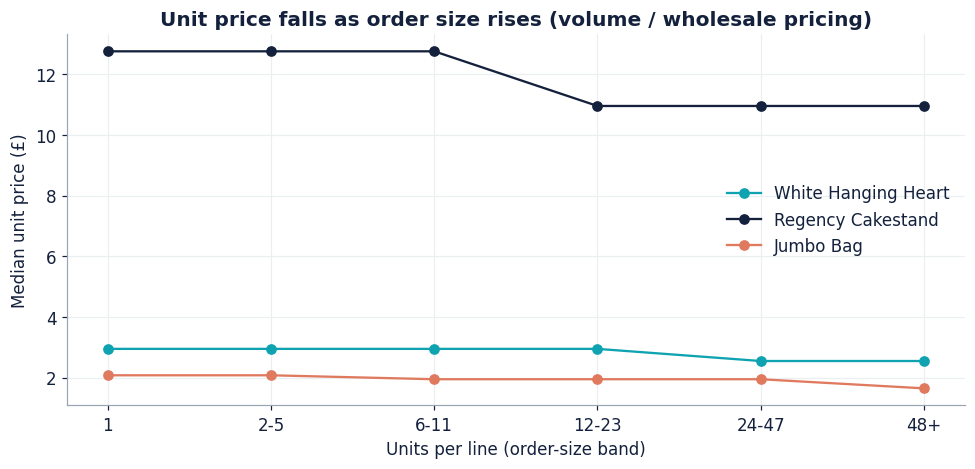

The same SKU sells cheaper in larger quantities — order size, not customer identity,
explains most of the price spread. (A formal price~quantity test could confirm.)


In [7]:
def band(q):
    return ("1" if q==1 else "2-5" if q<=5 else "6-11" if q<=11 else
            "12-23" if q<=23 else "24-47" if q<=47 else "48+")
order = ["1","2-5","6-11","12-23","24-47","48+"]
ex = sales[sales["StockCode"].isin(["85123A","22423","85099B"])].copy()
ex["qb"] = ex["Quantity"].map(band)
labels = {"85123A":"White Hanging Heart","22423":"Regency Cakestand","85099B":"Jumbo Bag"}
piv = ex.pivot_table(index="qb", columns="StockCode", values="Price", aggfunc="median").reindex(order)
fig, ax = plt.subplots()
for code_, col in zip(["85123A","22423","85099B"], [TEAL,NAVY,CORAL]):
    ax.plot(piv.index, piv[code_], marker="o", color=col, label=labels[code_])
ax.set_title("Unit price falls as order size rises (volume / wholesale pricing)")
ax.set_xlabel("Units per line (order-size band)"); ax.set_ylabel("Median unit price (£)"); ax.legend(frameon=False)
plt.tight_layout(); plt.show()
print("The same SKU sells cheaper in larger quantities — order size, not customer identity,")
print("explains most of the price spread. (A formal price~quantity test could confirm.)")

## 6. Returns — modest but rising

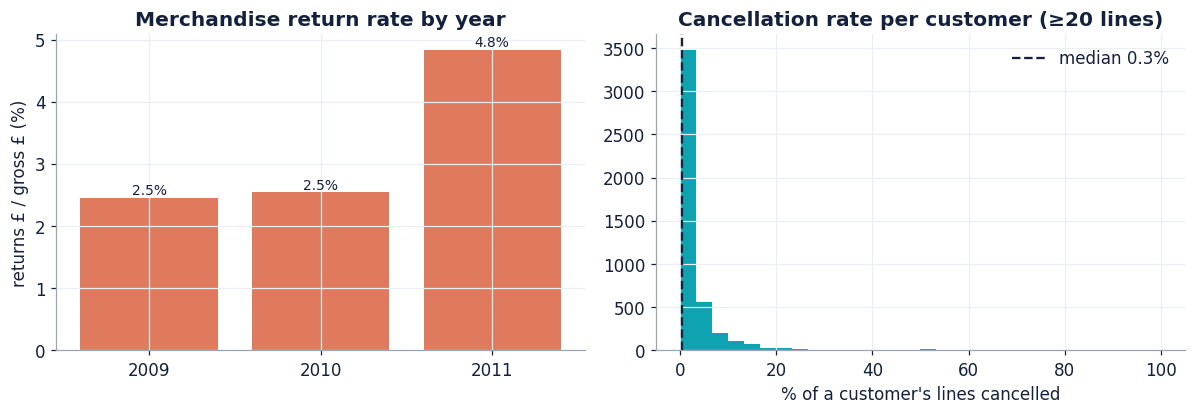

return rate by year: {2009: 2.5, 2010: 2.5, 2011: 4.8} | customers cancelling >50% of lines: 4


In [8]:
returns["year"] = returns["InvoiceDate"].dt.year
gy = sales.assign(y=sales["InvoiceDate"].dt.year).groupby("y")["Revenue"].sum()
ry = returns.groupby("year")["Revenue"].sum().reindex(gy.index).fillna(0)
rate = (-ry/gy*100)
cc = prep[prep["Customer ID"].notna()].copy()
by = cc.groupby("Customer ID").agg(n=("Invoice","size"), c=("is_cancellation","sum"))
by = by[by["n"]>=20]; by["r"] = by["c"]/by["n"]*100
fig, axes = plt.subplots(1,2, figsize=(11,3.9))
axes[0].bar(rate.index.astype(int).astype(str), rate.values, color=CORAL)
for x,v in zip(rate.index.astype(int).astype(str), rate.values):
    axes[0].text(x, v+0.05, f"{v:.1f}%", ha="center", color=NAVY, fontsize=9)
axes[0].set_title("Merchandise return rate by year"); axes[0].set_ylabel("returns £ / gross £ (%)")
axes[1].hist(by["r"], bins=30, color=TEAL)
axes[1].axvline(by["r"].median(), color=NAVY, ls="--", label=f"median {by['r'].median():.1f}%")
axes[1].set_title("Cancellation rate per customer (≥20 lines)"); axes[1].legend(frameon=False)
axes[1].set_xlabel("% of a customer's lines cancelled")
plt.tight_layout(); plt.show()
print("return rate by year:", {int(k):round(v,1) for k,v in rate.items()},
      f"| customers cancelling >50% of lines: {(by['r']>50).sum()}")

## 7. Deeper analysis

### 7a. Customer segments (RFM)

Score each identified customer on **Recency, Frequency, Monetary value** (quintiles), then group into intuitive segments.

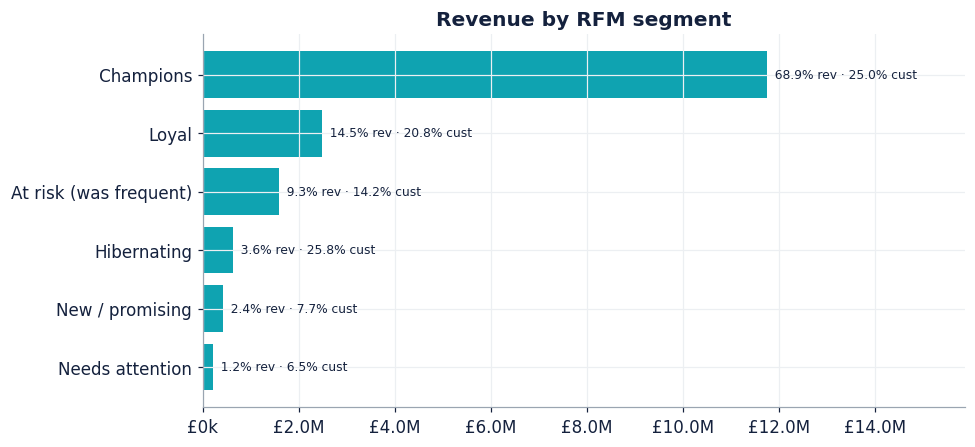

                        customers  cust_%  rev_%
segment                                         
Champions                    1463    25.0   68.9
Loyal                        1218    20.8   14.5
At risk (was frequent)        830    14.2    9.3
Hibernating                  1511    25.8    3.6
New / promising               448     7.7    2.4
Needs attention               382     6.5    1.2


In [9]:
snapshot = sales["InvoiceDate"].max() + pd.Timedelta(days=1)
rfm = sales.dropna(subset=["Customer ID"]).groupby("Customer ID").agg(
    recency=("InvoiceDate", lambda s: (snapshot - s.max()).days),
    frequency=("Invoice", "nunique"),
    monetary=("Revenue", "sum"))
# quintile scores (rank first to avoid duplicate bin edges); recency reversed (recent = better)
rfm["R"] = pd.qcut(rfm["recency"].rank(method="first"), 5, labels=[5,4,3,2,1]).astype(int)
rfm["F"] = pd.qcut(rfm["frequency"].rank(method="first"), 5, labels=[1,2,3,4,5]).astype(int)
rfm["M"] = pd.qcut(rfm["monetary"].rank(method="first"), 5, labels=[1,2,3,4,5]).astype(int)
def segment(r):
    R, F = r["R"], r["F"]
    if R >= 4 and F >= 4: return "Champions"
    if R >= 3 and F >= 3: return "Loyal"
    if R >= 4 and F <= 2: return "New / promising"
    if R <= 2 and F >= 3: return "At risk (was frequent)"
    if R <= 2 and F <= 2: return "Hibernating"
    return "Needs attention"
rfm["segment"] = rfm.apply(segment, axis=1)
seg = rfm.groupby("segment").agg(customers=("recency","size"), revenue=("monetary","sum"))
seg["rev_%"] = (seg["revenue"]/seg["revenue"].sum()*100).round(1)
seg["cust_%"] = (seg["customers"]/seg["customers"].sum()*100).round(1)
seg = seg.sort_values("revenue", ascending=True)
fig, ax = plt.subplots(figsize=(9,4.2))
ax.barh(seg.index, seg["revenue"].values, color=TEAL)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(money))
for i,(s,row) in enumerate(seg.iterrows()):
    ax.text(row["revenue"], i, f"  {row['rev_%']}% rev · {row['cust_%']}% cust", va="center", fontsize=8, color=NAVY)
ax.set_xlim(0, seg["revenue"].max()*1.35); ax.set_title("Revenue by RFM segment")
plt.tight_layout(); plt.show()
print(seg[["customers","cust_%","rev_%"]].sort_values("rev_%", ascending=False).to_string())

A small set of **Champions / Loyal** customers contributes a disproportionate share of revenue, while a large **Hibernating** tail contributes little — consistent with the Pareto view and typical of a wholesale base.

### 7b. Cohort retention

Group customers by the month of their first purchase, then track the share still active in later months.

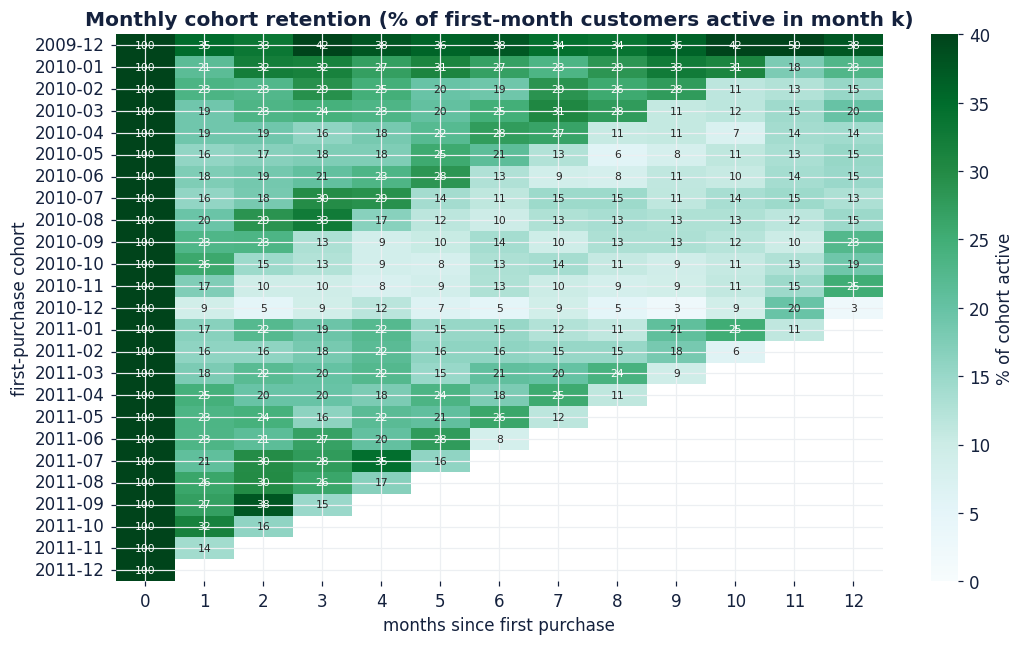

Average month-1 repeat rate across cohorts: 21% — most customers do not return the next month.


In [10]:
c = sales.dropna(subset=["Customer ID"]).copy()
c["order_month"] = c["InvoiceDate"].dt.to_period("M")
first = c.groupby("Customer ID")["order_month"].min().rename("cohort")
c = c.join(first, on="Customer ID")
c["k"] = (c["order_month"].dt.year - c["cohort"].dt.year)*12 + (c["order_month"].dt.month - c["cohort"].dt.month)
counts = c.groupby(["cohort","k"])["Customer ID"].nunique().unstack()
retention = counts.divide(counts[0], axis=0) * 100
ret = retention.iloc[:, :13]
ret.index = ret.index.astype(str)
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(ret, cmap="BuGn", annot=True, fmt=".0f", annot_kws={"size":7}, vmin=0, vmax=40,
            cbar_kws={"label":"% of cohort active"}, ax=ax)
ax.set_title("Monthly cohort retention (% of first-month customers active in month k)")
ax.set_xlabel("months since first purchase"); ax.set_ylabel("first-purchase cohort")
plt.tight_layout(); plt.show()
m1 = retention[1].mean()
print(f"Average month-1 repeat rate across cohorts: {m1:.0f}% — most customers do not return the next month.")

Retention is **irregular, not absent**. Only ~21% of a cohort returns the *following* month, so purchasing is lumpy — yet over the two-year window the **majority reorder** (the model below shows a ~72% eventual-repeat base). That fits a wholesale pattern of infrequent restocking: the lever is reorder **timing and frequency**, not a simple one-and-done churn problem.

### 7c. Market-basket / product affinity

Which products are bought together? We measure co-occurrence and **lift** among the most common products (lift > 1 = bought together more than chance).

                            product_A                          product_B  baskets  support_%  lift
0            RED SPOTTY CHARLOTTE BAG   CHARLOTTE BAG , PINK/WHITE SPOTS     1077        3.7   9.7
1              WOODLAND CHARLOTTE BAG        CHARLOTTE BAG , SUKI DESIGN      838        2.9   8.9
2      SWEETHEART CERAMIC TRINKET BOX     STRAWBERRY CERAMIC TRINKET BOX     1109        3.8   8.9
3              WOODLAND CHARLOTTE BAG   CHARLOTTE BAG , PINK/WHITE SPOTS      764        2.6   8.9
4      JUMBO BAG SCANDINAVIAN PAISLEY     JUMBO BAG PINK VINTAGE PAISLEY      757        2.6   8.8
5         CHARLOTTE BAG , SUKI DESIGN   CHARLOTTE BAG , PINK/WHITE SPOTS      833        2.9   8.7
6              WOODLAND CHARLOTTE BAG           RED SPOTTY CHARLOTTE BAG      926        3.2   8.4
7          CHOCOLATE HOT WATER BOTTLE  HOT WATER BOTTLE TEA AND SYMPATHY      776        2.7   8.2
8   WOODEN PICTURE FRAME WHITE FINISH        WOODEN FRAME ANTIQUE WHITE      1078        3.7   7.9
9         

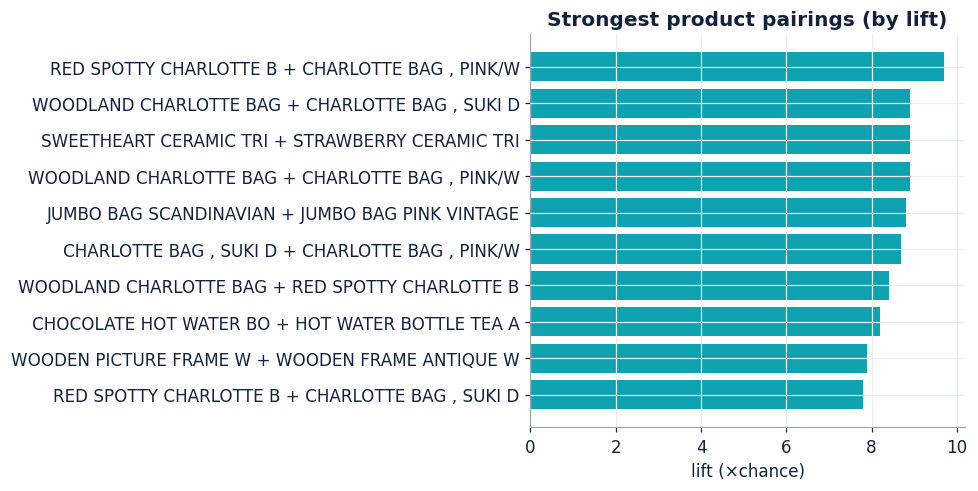

In [11]:
topN = sales["StockCode"].value_counts().head(60).index
basket = sales[sales["StockCode"].isin(topN)]
pair, item = Counter(), Counter()
for _, grp in basket.groupby("Invoice")["StockCode"]:
    items = set(grp)
    for it in items: item[it] += 1
    for a, b in combinations(sorted(items), 2): pair[(a,b)] += 1
n_inv = basket["Invoice"].nunique()
desc = sales.drop_duplicates("StockCode").set_index("StockCode")["Description"]
rows = []
for (a,b), cnt in pair.items():
    lift = (cnt/n_inv) / ((item[a]/n_inv)*(item[b]/n_inv))
    rows.append((desc.get(a,a), desc.get(b,b), cnt, round(cnt/n_inv*100,1), round(lift,1)))
aff = (pd.DataFrame(rows, columns=["product_A","product_B","baskets","support_%","lift"])
         .query("baskets >= 40").sort_values("lift", ascending=False).head(12).reset_index(drop=True))
print(aff.to_string())
top10 = aff.head(10)[::-1]
fig, ax = plt.subplots(figsize=(9,4.6))
ax.barh([f"{a[:22]} + {b[:22]}" for a,b in zip(top10["product_A"], top10["product_B"])],
        top10["lift"], color=TEAL)
ax.set_title("Strongest product pairings (by lift)"); ax.set_xlabel("lift (×chance)")
plt.tight_layout(); plt.show()

Clear affinities emerge among themed ranges (e.g. matching colourways / sets bought together), pointing to **bundling and cross-sell** opportunities — and to which products anchor a basket.

### 7d. A first predictive baseline — will a customer buy again?

Using **only a customer's first order** (no leakage), predict whether they place a second. An honest baseline, not a production model.

customers: 5,852 | repeat rate (base): 72%


ROC-AUC — random forest: 0.68 | logistic: 0.61


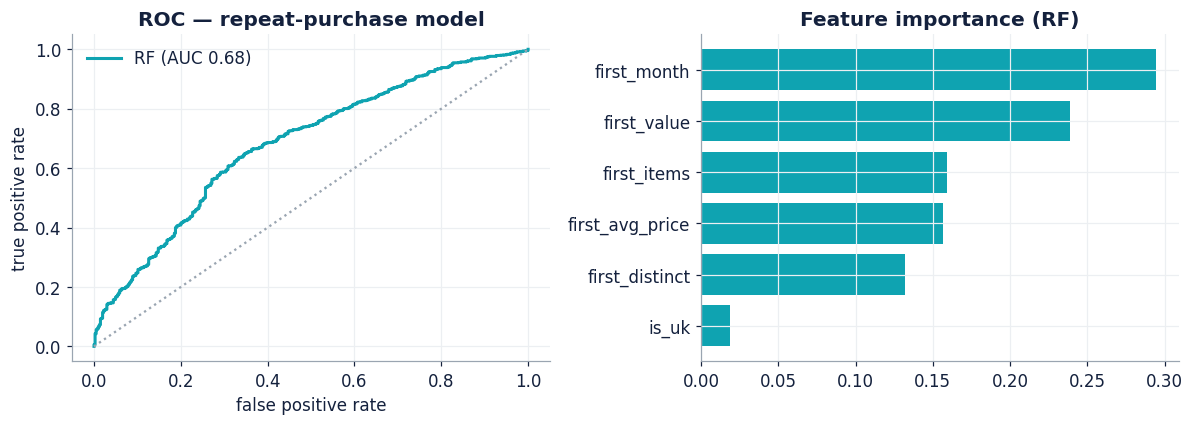

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve

c = sales.dropna(subset=["Customer ID"]).copy()
n_orders = c.groupby("Customer ID")["Invoice"].nunique()
first_date = c.groupby("Customer ID")["InvoiceDate"].transform("min")
first_lines = c[c["InvoiceDate"] == first_date]                 # lines of each customer's first order
feat = first_lines.groupby("Customer ID").agg(
    first_value=("Revenue","sum"), first_items=("Quantity","sum"),
    first_distinct=("StockCode","nunique"), first_avg_price=("Price","mean"),
    first_month=("InvoiceDate", lambda s: s.dt.month.iloc[0]),
    is_uk=("Country", lambda s: int((s=="United Kingdom").iloc[0])))
feat["label"] = (n_orders.reindex(feat.index) >= 2).astype(int)
print(f"customers: {len(feat):,} | repeat rate (base): {feat['label'].mean()*100:.0f}%")

X = feat[["first_value","first_items","first_distinct","first_avg_price","first_month","is_uk"]]
y = feat["label"]
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
rf  = RandomForestClassifier(n_estimators=300, max_depth=8, class_weight="balanced", random_state=42).fit(Xtr, ytr)
logit = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, class_weight="balanced")).fit(Xtr, ytr)
auc_rf  = roc_auc_score(yte, rf.predict_proba(Xte)[:,1])
auc_lr  = roc_auc_score(yte, logit.predict_proba(Xte)[:,1])
print(f"ROC-AUC — random forest: {auc_rf:.2f} | logistic: {auc_lr:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fpr, tpr, _ = roc_curve(yte, rf.predict_proba(Xte)[:,1])
axes[0].plot(fpr, tpr, color=TEAL, lw=2, label=f"RF (AUC {auc_rf:.2f})")
axes[0].plot([0,1],[0,1], color=GRAY, ls=":"); axes[0].legend(frameon=False)
axes[0].set_title("ROC — repeat-purchase model"); axes[0].set_xlabel("false positive rate"); axes[0].set_ylabel("true positive rate")
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values()
axes[1].barh(imp.index, imp.values, color=TEAL); axes[1].set_title("Feature importance (RF)")
plt.tight_layout(); plt.show()

The model beats chance only **modestly (AUC ≈ 0.68)**. With a **~72% base repeat rate**, most customers eventually reorder — so the useful question is *when / how often* they return, not simply *whether*. First-order **value, size and breadth** carry the most signal. A production version would use a **time-based split** and richer behavioural features (inter-order gaps, engagement, channel) rather than first-order attributes alone.

## 8. Findings & hypotheses

| # | Finding / hypothesis | Why it matters | Confidence |
|---|----------------------|----------------|-----------|
| 1 | **Revenue is highly concentrated** — UK ~86% of revenue, top 20% of customers ~77%, and unit price falls with order size (wholesale/volume pricing). | A lost account is a revenue event; account management and retention matter more than shopper acquisition. | **Medium-High** |
| 2 | **Demand peaks in November**; December is truncated/unreliable. | Plan inventory & cash-flow around the autumn build-up. | **High** (Nov) |
| 3 | **Merchandise returns are modest but rising** (~2.5% → ~4.8%), with a tail of high-cancellation accounts. | Forecast on net, not gross; review the worst accounts. | **Medium** |
| 4 | **Purchasing is irregular but repeat-heavy** — only ~21% reorder the next month, yet ~72% reorder within two years; first-order features predict repeat only weakly (AUC ≈ 0.68). | The lever is reorder **timing/frequency**, not one-and-done churn. | **Medium-High** |
| 5 | **Clear product affinities & category concentration** (Kitchen + Home ≈ 37%). | Bundling, cross-sell and range/inventory focus. | **Medium** (categories are heuristic) |
| 6 | **~23% of sales are unattributed** and behave differently — possibly a separate retail/marketplace channel. | If systematic, customer metrics describe only the identified segment. | **Medium** — needs business confirmation |

## 9. Recommendations & next steps

1. **Protect and grow top accounts** — the top 20% drive ~77% of revenue; monitor concentration
   and churn risk on Champions / Loyal segments.
2. **Lift reorder frequency & timing** — most accounts reorder eventually (~72%) but slowly and
   irregularly (only ~21% the next month); test replenishment / nurture prompts and reactivate
   lapsed accounts, measured with cohorts.
3. **Use affinities for bundling / cross-sell** — merchandise the strong product pairings and
   category leaders (Kitchen, Home Décor).
4. **Plan around the autumn peak** — inventory & cash-flow for the Sep–Nov build-up.
5. **Close the data gaps** (from Notebook 1) — line-level ID, a data dictionary, a channel flag
   for unattributed sales, and cost data to move from revenue to **margin**; then revisit the
   model with a proper time-based split and richer features.